In [4]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.models import Model

In [8]:
# Data
df = pd.read_csv('bbc_text.csv')
df['targets'] = df['labels'].astype("category").cat.codes
df_train, df_test = train_test_split(df, test_size= 0.2)

In [11]:
# TFIDF Vectors
tfidf = TfidfVectorizer(stop_words='english')

Xtrain = tfidf.fit_transform(df_train['text'])
Ytrain = df_train['targets']

Xtest = tfidf.transform(df_test['text'])
Ytest = df_test['targets']

In [10]:
# Building Model
K = df['targets'].max() + 1
D = Xtrain.shape[1]
i = Input(shape=(D,))
x = Dense(300, activation='relu')(i)
x = Dense(K)(x)
model = Model(i, x)
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 26705)]           0         
                                                                 
 dense (Dense)               (None, 300)               8011800   
                                                                 
 dense_1 (Dense)             (None, 5)                 1505      
                                                                 
Total params: 8,013,305
Trainable params: 8,013,305
Non-trainable params: 0
_________________________________________________________________


In [12]:
model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer='adam',
    metrics=['accuracy']
)

Xtrain = Xtrain.toarray()
Xtest = Xtest.toarray()

In [13]:
# Trainig
r = model.fit(
    Xtrain, Ytrain,
    validation_data=(Xtest, Ytest),
    epochs = 10,
    batch_size = 128
)

Epoch 1/10
14/14 [==============================] - 3s 135ms/step - loss: 1.4322 - accuracy: 0.8629 - val_loss: 1.1536 - val_accuracy: 0.9596
Epoch 2/10
14/14 [==============================] - 2s 122ms/step - loss: 0.8330 - accuracy: 0.9938 - val_loss: 0.6548 - val_accuracy: 0.9663
Epoch 3/10
14/14 [==============================] - 2s 123ms/step - loss: 0.3680 - accuracy: 0.9966 - val_loss: 0.3566 - val_accuracy: 0.9663
Epoch 4/10
14/14 [==============================] - 2s 117ms/step - loss: 0.1522 - accuracy: 0.9978 - val_loss: 0.2297 - val_accuracy: 0.9708
Epoch 5/10
14/14 [==============================] - 2s 118ms/step - loss: 0.0734 - accuracy: 0.9989 - val_loss: 0.1774 - val_accuracy: 0.9708
Epoch 6/10
14/14 [==============================] - 2s 117ms/step - loss: 0.0430 - accuracy: 1.0000 - val_loss: 0.1515 - val_accuracy: 0.9708
Epoch 7/10
14/14 [==============================] - 2s 117ms/step - loss: 0.0291 - accuracy: 1.0000 - val_loss: 0.1374 - val_accuracy: 0.9663
Epoch 

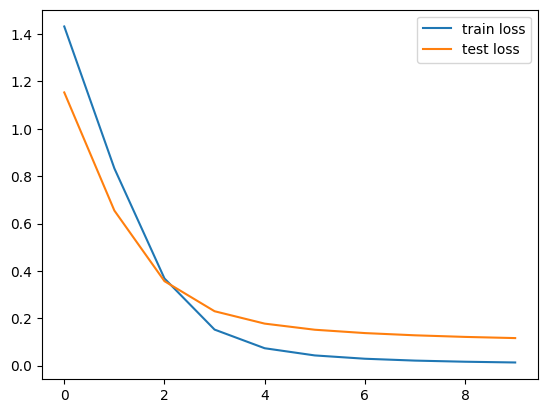

In [16]:
plt.plot(r.history['loss'], label='train loss')
plt.plot(r.history['val_loss'], label='test loss')
plt.legend()